## EX10
`Author: Hongru He`
### Part 1 - Implementation

#### Step 1 - Baseline Random Forest

In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the data from OpenML
# The 'mnist_784' dataset has 784 features (28*28 pixels)
mnist = fetch_openml('mnist_784', version=1, parser='pandas')
print(f"Dataset shape: {mnist.data.shape}")

Dataset shape: (70000, 784)


In [2]:
# 2. Split the dataset
X, y = mnist['data'], mnist['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

print(f"Training shape: {X_train.shape}")

Training shape: (60000, 784)


In [3]:
from sklearn.ensemble import RandomForestClassifier
import time

# 3. Initiate model
model_rfc = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)

# 4. Record the start time
start_time = time.time()

# 5. Train the model
print("Training the Random Forest... (this may take a moment)")
model_rfc.fit(X_train, y_train)

# 6. Record the end time and calculate training time
end_time = time.time()
training_duration = end_time - start_time

print(f"Training complete!")
print(f"Total training time: {training_duration:.2f} seconds")

Training the Random Forest... (this may take a moment)
Training complete!
Total training time: 3.82 seconds


In [4]:
y_pred = model_rfc.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

Overall Accuracy: 96.92%


In [5]:
# Detailed classification report
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       983
           1       0.99      0.99      0.99      1152
           2       0.95      0.98      0.96       967
           3       0.95      0.95      0.95      1034
           4       0.96      0.97      0.97       906
           5       0.98      0.96      0.97       937
           6       0.98      0.98      0.98       961
           7       0.97      0.97      0.97      1055
           8       0.96      0.95      0.96       969
           9       0.96      0.95      0.96      1036

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



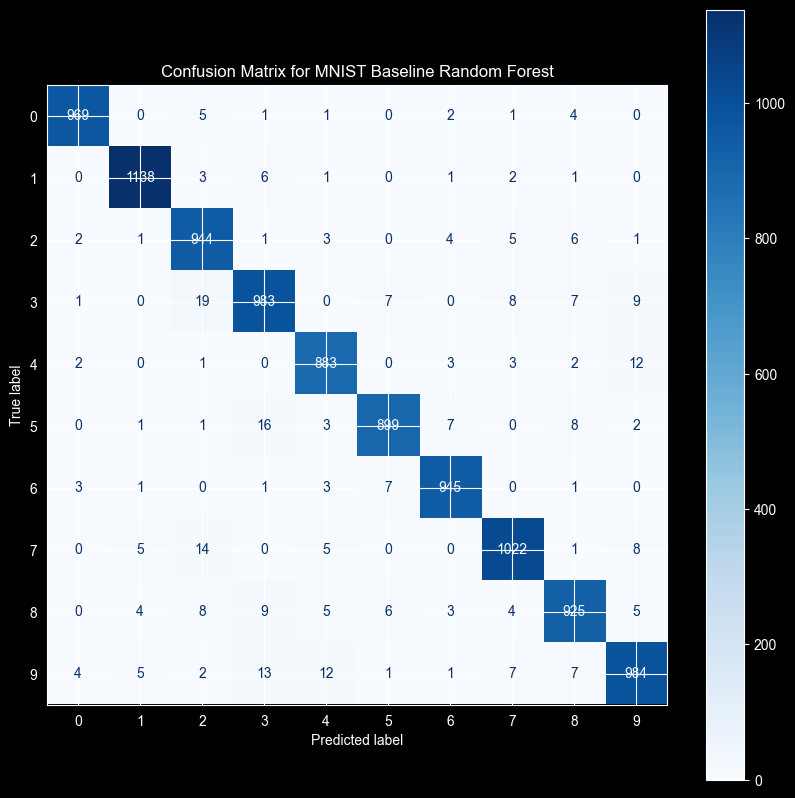

In [6]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
plt.title("Confusion Matrix for MNIST Baseline Random Forest")
plt.show()

#### Step 2 - Apply PCA

In [7]:
from sklearn.decomposition import PCA

# 1. Initialize PCA to preserve 95% of the variance
pca = PCA(n_components=0.95)

# 2. Fit on the training set and transform both sets
# Note: PCA should be "fit" only on the training data to avoid data leakage
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

# 3. Check the results
print(f"Original number of features: {X_train.shape[1]}")
print(f"Reduced number of features: {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")

Original number of features: 784
Reduced number of features: 154
Explained variance ratio: 0.9504


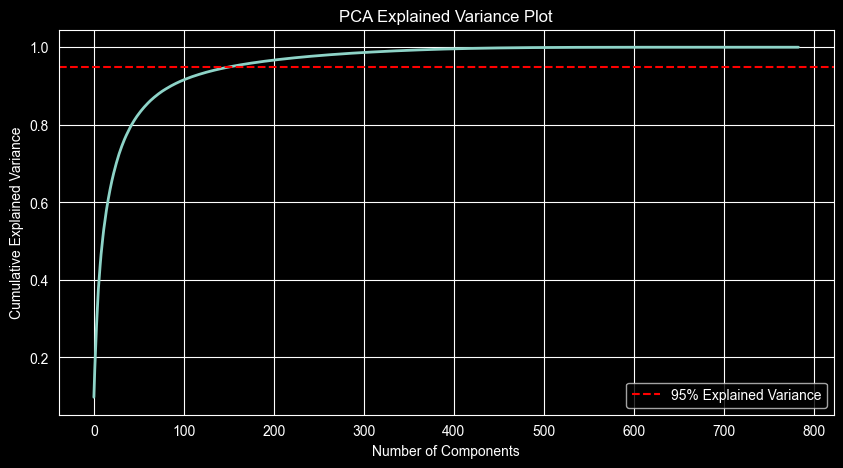

In [21]:
# Explained Variance Plot
import numpy as np

# Detect the cumulative variance
pca_full = PCA().fit(X_train) # Fit on all components to see the full curve
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), linewidth=2)

# Mark the 95% threshold
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Plot')
plt.grid(True)
plt.legend()
plt.show()

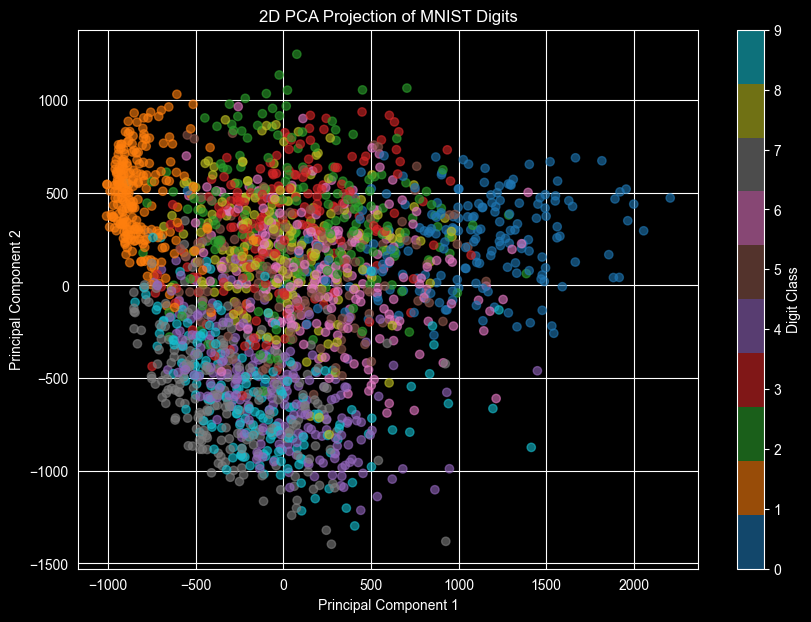

In [22]:
# PCA Scatter Plot
# Project data to 2 dimensions for visualization
pca_2d = PCA(n_components=2)
X_vis = pca_2d.fit_transform(X_train[:2000]) # Use a subset for faster plotting
y_vis = y_train[:2000].astype(int)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Digit Class')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection of MNIST Digits')
plt.show()

In [8]:
# Train a new RFC
# 1. Initialize a new classifier
model_rfc_reduced = RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                       random_state=42)

# 2. Record the start time
start_time_pca = time.time()

# 3. Train on the PCA-reduced training set
print("Training the Random Forest on PCA-reduced data...")
model_rfc_reduced.fit(X_train_reduced, y_train)

# 4. Record the end time
end_time_pca = time.time()
training_duration_pca = end_time_pca - start_time_pca

print(f"Training complete!")
print(f"PCA Training time: {training_duration_pca:.2f} seconds")
print(f"Speedup factor: {training_duration / training_duration_pca:.2f}x")

Training the Random Forest on PCA-reduced data...
Training complete!
PCA Training time: 10.64 seconds
Speedup factor: 0.36x


In [9]:
# Evaluate the model performance
# Predict using the PCA-trained model
# Remember: X_test_reduced was already transformed using the same PCA mapping
y_pred_pca = model_rfc_reduced.predict(X_test_reduced)

# Calculate Accuracy
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"PCA Model Accuracy: {accuracy_pca * 100:.2f}%")

PCA Model Accuracy: 94.84%


In [10]:
# Compare with original accuracy
if 'accuracy' in locals():
    diff = accuracy - accuracy_pca
    print(f"Accuracy Drop: {diff * 100:.2f}%")

Accuracy Drop: 2.08%


In [11]:
# Detailed Classification Report
print("\nPCA Model Classification Report:")
print(classification_report(y_test, y_pred_pca))


PCA Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       983
           1       0.97      0.98      0.98      1152
           2       0.95      0.96      0.95       967
           3       0.92      0.94      0.93      1034
           4       0.92      0.95      0.94       906
           5       0.94      0.94      0.94       937
           6       0.96      0.97      0.97       961
           7       0.96      0.96      0.96      1055
           8       0.94      0.89      0.92       969
           9       0.94      0.92      0.93      1036

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



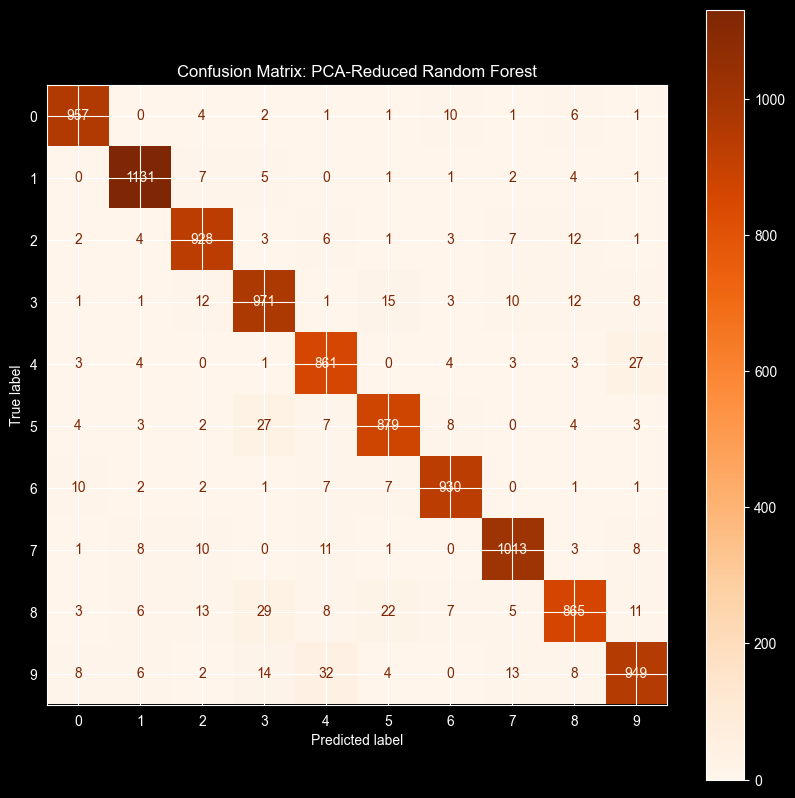

In [12]:
# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pca, ax=ax, cmap='Oranges')
plt.title("Confusion Matrix: PCA-Reduced Random Forest")
plt.show()

#### Questions to consider
1. Was training significantly faster?
No. In fact, it was significantly slower.
    - Original Training Time: 3.82 seconds.
    - PCA Training Time: 10.64 seconds.
    - Speedup Factor: 0.36x (meaning it took roughly 2.8 times longer to train on the reduced dataset).<br><br>

2. How did the model’s performance compare to the baseline?
The performance dropped slightly.
    - Original Accuracy: 96.92%.
    - PCA Accuracy: 94.84%.
    - Accuracy Drop: 2.08%. While you retained 95% of the variance, that missing 5% contained fine-grained details necessary for the Random Forest to distinguish between similar digits.

#### Step 3 - Try with SGDClassifier

##### SGD on Original Dataset

In [15]:
from sklearn.linear_model import SGDClassifier

# Initialize SGD
sgd_clf = SGDClassifier(random_state=42)

# Train on Full Data
start_full = time.time()

print("Training the SGDClassifier on original data...")
sgd_clf.fit(X_train, y_train)
end_full = time.time()

print(f"Training complete!")
print(f"Full Data SGD Training Time: {end_full - start_full:.2f}s")

Training the SGDClassifier on original data...
Training complete!
Full Data SGD Training Time: 66.97s


In [16]:
# Evaluate
y_pred_sgd = sgd_clf.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_sgd)

print(f"Full Data SGD Accuracy: {acc_full * 100:.2f}%")

Full Data SGD Accuracy: 86.91%


##### SGD on PCA-Reduced Dataset

In [17]:
# Initialize New SGD
sgd_clf_pca = SGDClassifier(random_state=42)

# Train on PCA Data
start_pca = time.time()

print("Training the SGDClassifier on PCA-reduced data...")
sgd_clf_pca.fit(X_train_reduced, y_train)
end_pca = time.time()

print(f"Training complete!")
print(f"PCA-Reduced SGD Training Time: {end_pca - start_pca:.2f}s")
print(f"Speedup Factor: {(end_full - start_full) / (end_pca - start_pca):.2f}x")

Training the SGDClassifier on PCA-reduced data...
Training complete!
PCA-Reduced SGD Training Time: 12.16s
Speedup Factor: 5.51x


In [18]:
# Evaluate
y_pred_sgd_pca = sgd_clf_pca.predict(X_test_reduced)
acc_pca = accuracy_score(y_test, y_pred_sgd_pca)

print(f"PCA-Reduced SGD Accuracy: {acc_pca * 100:.2f}%")

PCA-Reduced SGD Accuracy: 89.07%


In [20]:
# Compare with original accuracy
if 'acc_full' in locals():
    diff_sgd = acc_pca - acc_full
    print(f"Accuracy Increase: {diff_sgd * 100:.2f}%")

Accuracy Increase: 2.16%


#### Questions to consider
1. How much does PCA help when using SGDClassifier compared to Random Forest?
    PCA helped the SGDClassifier immensely, providing both a massive speedup and a performance boost—the exact opposite of the Random Forest result.
    - Speedup: The SGD training went from 66.97s (Original) to 12.16s (PCA), a 5.51x speedup.
    - Performance: The accuracy actually increased by 2.16% (from 86.91% to 89.07%). <br><br>

2. Why might the effect differ between model types?
    The difference comes down to how these two algorithms "look" at data:
   - Random Forest (Tree-based):
      - Sparsity vs. Density: Original MNIST pixels are "sparse" (mostly zeros). Trees can skip zero-value features almost instantly. PCA turns those sparse pixels into dense floating-point numbers. Even though there are fewer features (154 vs 784), the Random Forest now has to perform a calculation for every single feature at every node, making it slower.
      - Axis-Aligned Splits: Trees split data with vertical or horizontal lines. PCA rotates data into complex diagonal shapes that are harder for trees to "cut" efficiently.<br><br>
   - SGDClassifier (Linear-based):
      - Computational Complexity: SGD performs a dot product ($w \cdot x$). Calculating a dot product with 154 features is mathematically 5 times faster than with 784 features.
      - Signal-to-Noise: Linear models like SGD are very sensitive to noise. By using PCA to keep 95% variance, you effectively "filtered" out the 5% of noise in the background pixels, which is why your accuracy actually improved.

### Part 2 - Reflection & Summary
1. PCA in Practice: Dimensionality and Performance
Applying PCA to the MNIST dataset demonstrated that reducing data dimensionality **from 784 features to 154** (preserving 95% variance) has vastly different impacts depending on the model architecture. While the feature space was compressed by approximately **80%**, the effect on training time was not universally positive. For the **SGDClassifier**, PCA acted as a powerful optimization tool, cutting training time by over **5.5x** and even slightly **increasing accuracy by 2.16%**. This suggests that for linear models, PCA successfully filters out low-variance noise that can otherwise hinder convergence and predictive power. <br><br>

2. Observations and Surprises
The most surprising observation was the "PCA Paradox" encountered with the **Random Forest** model, where reducing dimensionality actually made the model **2.8 times slower**. This occurs because PCA transforms sparse, integer-based pixel data into dense, floating-point principal components, forcing the decision trees to perform more complex calculations at every split. Additionally, the Random Forest suffered a **2.08% accuracy drop**, indicating that the 5% of discarded variance contained subtle spatial details crucial for the trees to differentiate between similar digits like 4s and 9s. Ultimately, PCA is highly effective for **gradient-based linear models** but can be a "speed trap" for **tree-based algorithms**.